# Recompute evaluator details for human-vs-synthetic GT scatter

This notebook avoids stale cached onset-pointwise detail tables by recomputing evaluator rows from raw CVS-Act GT JSONL and model prediction files before computing system-level final-score correlations.

/mnt/md0/weiqiuy/surgent/.venv/lib/python3.12/site-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


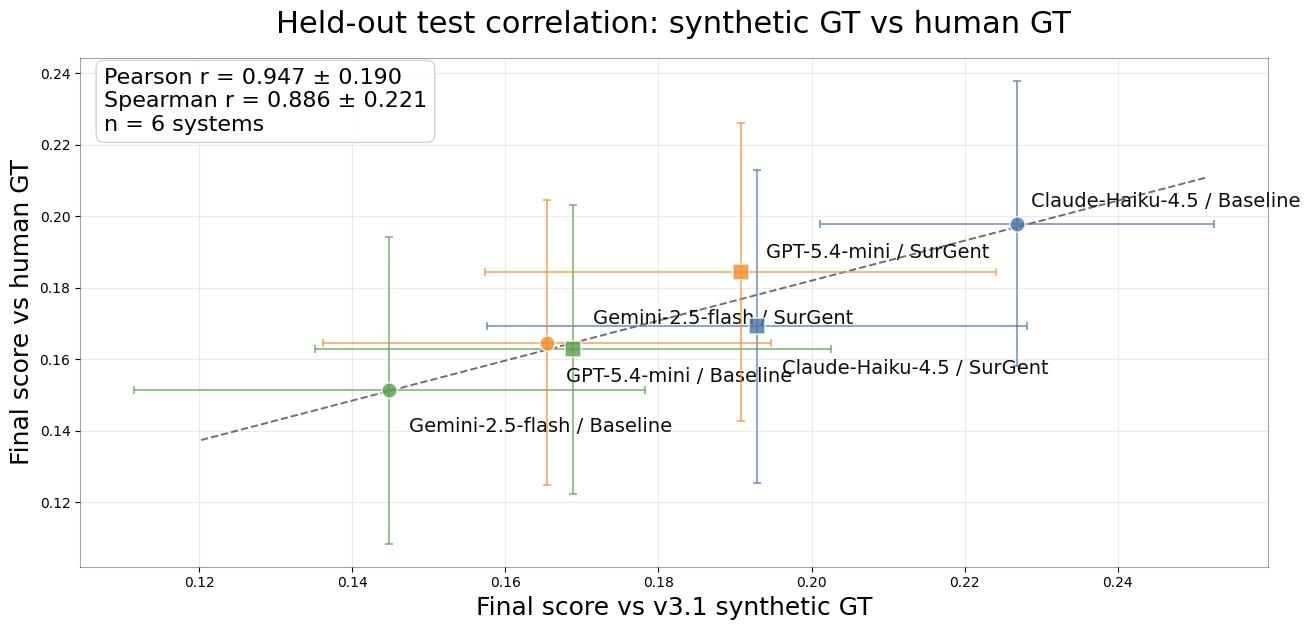

 split_seed split  n_systems  n_test_videos_in_seed_split  human_gt_records_n  synthetic_gt_records_n  human_details_videos  synthetic_details_videos  common_details_videos  bootstrap_examples_n  bootstrap_resamples_n  pearson_r  pearson_bootstrap_std  pearson_bootstrap_ci_low  pearson_bootstrap_ci_high  spearman_r  spearman_bootstrap_std  spearman_bootstrap_ci_low  spearman_bootstrap_ci_high
   20260610  test          6                           20                  60                      60                    20                        20                     20                    60                   1000    0.94725               0.189873                  0.269943                   0.968075    0.885714                0.220545                        0.2                         1.0
model_short       model_name raw_variant_label variant_label                system_label  Human GT  v3.1 synthetic GT  Human GT bootstrap std  v3.1 synthetic GT bootstrap std  synthetic_minus_human
     claud

In [1]:

from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display, Markdown

ROOT_DIR = Path('/mnt/md0/weiqiuy/surgent')
OUT_DIR = ROOT_DIR / 'notebooks/artifacts/cvs_act_human_synthetic_correlation_recomputed_details'
OUT_DIR.mkdir(parents=True, exist_ok=True)

for path in [ROOT_DIR / 'scripts/eval', ROOT_DIR / 'src']:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from evaluate_cvs_act_v1_combined import load_synthetic_action_records, collect_prediction_groups
from evaluate_audit_v11_simple_recommendation import gt_records_by_video
from evaluate_cvs_act_v1_onset_pointwise import collect_eval_points, evaluate_points

SPLIT_SEED = 20260610
SPLIT_CSV = ROOT_DIR / 'notebooks/artifacts/qwen3.5_audit_v11_current_best_prompt_summary/validation_test_video_split_seed20260610.csv'
HUMAN_GT_JSONL = ROOT_DIR / 'hf_repos/cvs-act/sages_trained_annotator/test.jsonl'
SYNTHETIC_GT_JSONL = ROOT_DIR / 'hf_repos/cvs-act/sages_synthetic/test.jsonl'

prediction_dirs = [
    ROOT_DIR / 'outputs/cot_audit_v11_simple/cot_fixedk3_norecdescs_fmeta',
    ROOT_DIR / 'outputs/surgent_sequential_agent_audit_v11_simple/cot/pref-cvs_arec_steps5_fixedk3_norecdescs_fmeta',
]
model_filter = {'claude-haiku-4-5-20251001', 'gemini-2.5-flash', 'gpt-5.4-mini'}
taxonomy_filter = {'cvs_act_current_simple_v1'}

split_df = pd.read_csv(SPLIT_CSV)
test_videos = set(split_df.loc[split_df['split'].eq('test'), 'video_id'].astype(str))
assert len(test_videos) == 20

model_display = {
    'claude': 'Claude-Haiku-4.5',
    'gemini': 'Gemini-2.5-flash',
    'gpt': 'GPT-5.4-mini',
}
model_color_map = {'claude': '#4C78A8', 'gemini': '#59A14F', 'gpt': '#F28E2B'}
variant_display = {'Baseline default': 'Baseline', 'SurGent default': 'SurGent'}
variant_marker_map = {'Baseline default': 'o', 'SurGent default': 's'}
final_components = [('left', 'exact'), ('right', 'medium'), ('camera', 'coarse')]
BOOTSTRAP_N = 1000


def bool_value(value):
    if pd.isna(value):
        return False
    if isinstance(value, str):
        return value.strip().lower() in {'true', '1', 'yes'}
    return bool(value)


def local_multiclass_macro_f1(y_true, y_pred):
    labels = sorted(set(y_true) | set(y_pred))
    vals = []
    for label in labels:
        tp = sum((t == label) and (p == label) for t, p in zip(y_true, y_pred))
        fp = sum((t != label) and (p == label) for t, p in zip(y_true, y_pred))
        fn = sum((t == label) and (p != label) for t, p in zip(y_true, y_pred))
        denom = 2 * tp + fp + fn
        vals.append((2 * tp / denom) if denom else 0.0)
    return float(np.mean(vals)) if vals else np.nan


def load_gt_records_for_test(path):
    records = load_synthetic_action_records(path)
    out = []
    for record in records:
        record.setdefault('clip_level', 'coarse')
        if str(record.get('video_id')) in test_videos:
            out.append(record)
    return out


def recompute_details(records, gt_source):
    gt_by_video = gt_records_by_video(records)
    frames_by_method, paths_by_method, skipped = collect_prediction_groups(
        prediction_dirs,
        gt_by_video,
        include_partial=False,
        modified_since=None,
        model_filter=model_filter,
        taxonomy_filter=taxonomy_filter,
        verbose=False,
    )
    rows = evaluate_points(frames_by_method, collect_eval_points(records))
    details = pd.DataFrame(rows)
    if not details.empty:
        details['gt_source'] = gt_source
        details['video_id_str'] = details['video_id'].astype(str)
    inventory = []
    for method, by_video in sorted(frames_by_method.items()):
        inventory.append({
            'gt_source': gt_source,
            'method': method,
            'n_prediction_videos': len(by_video),
            'n_test_videos_with_gt_records': len(gt_by_video),
        })
    skipped_df = pd.DataFrame(skipped)
    if not skipped_df.empty:
        skipped_df['gt_source'] = gt_source
    return details, pd.DataFrame(inventory), skipped_df


def filtered_component_rows(details_df, video_ids, model_short, variant_label, actor):
    sub = details_df[
        details_df['video_id_str'].isin({str(v) for v in video_ids})
        & details_df['model_short'].eq(model_short)
        & details_df['variant_label'].eq(variant_label)
        & details_df['clip_level'].eq('coarse')
        & details_df['point_source'].eq('coarse_actor_onset')
        & details_df['actor'].eq(actor)
    ].copy()
    if sub.empty:
        return sub
    return sub[
        sub['gt_present'].map(bool_value)
        & ~sub['gt_presence_excluded_uncertain'].map(bool_value)
        & ~sub['gt_presence_unknown'].map(bool_value)
    ].copy()


def component_score_from_rows(rows, granularity):
    if rows.empty:
        return np.nan, 0
    gt_col = f'gt_label_resolved_{granularity}'
    pred_col = f'pred_label_{granularity}'
    usable = rows.dropna(subset=[gt_col, pred_col])
    if usable.empty:
        return np.nan, 0
    y_true = usable[gt_col].astype(str).tolist()
    y_pred = usable[pred_col].astype(str).tolist()
    return local_multiclass_macro_f1(y_true, y_pred), len(usable)


def clip_final_score_series_from_details(details_df, model_short, variant_label):
    component_series = []
    for actor, granularity in final_components:
        rows = filtered_component_rows(details_df, test_videos, model_short, variant_label, actor)
        match_col = f'label_match_{granularity}'
        if rows.empty or match_col not in rows:
            continue
        usable = rows.dropna(subset=[match_col]).copy()
        if usable.empty:
            continue
        usable['clip_score'] = usable[match_col].map(bool_value).astype(float)
        component_name = f'{actor}_{granularity}'
        # Multiple actor-onset rows can come from the same clip; average them once here.
        component_series.append(usable.groupby('example_id')['clip_score'].mean().rename(component_name))
    if not component_series:
        return pd.Series(dtype=float, name='clip_final_score')
    clip_component_df = pd.concat(component_series, axis=1)
    return clip_component_df.mean(axis=1, skipna=True).dropna().rename('clip_final_score')


def clip_final_scores_from_details(details_df, model_short, variant_label):
    return clip_final_score_series_from_details(details_df, model_short, variant_label).to_numpy(dtype=float)


def bootstrap_mean_std(values, seed, n_boot=BOOTSTRAP_N):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size < 2:
        return np.nan
    rng = np.random.default_rng(seed)
    sample_idx = rng.integers(0, values.size, size=(n_boot, values.size))
    boot_means = values[sample_idx].mean(axis=1)
    return float(np.std(boot_means, ddof=1))


def build_clip_score_table(human_details, synthetic_details):
    rows = []
    source_details = {
        'Human GT': human_details,
        'v3.1 synthetic GT': synthetic_details,
    }
    for gt_source, details_df in source_details.items():
        for model_short in ['claude', 'gemini', 'gpt']:
            for raw_variant_label in ['Baseline default', 'SurGent default']:
                series = clip_final_score_series_from_details(details_df, model_short, raw_variant_label)
                for example_id, score in series.items():
                    rows.append({
                        'gt_source': gt_source,
                        'model_short': model_short,
                        'model_name': model_display[model_short],
                        'raw_variant_label': raw_variant_label,
                        'variant_label': variant_display[raw_variant_label],
                        'system_label': f'{model_display[model_short]} / {variant_display[raw_variant_label]}',
                        'example_id': example_id,
                        'clip_final_score': float(score),
                    })
    return pd.DataFrame(rows)


def bootstrap_correlations_from_clip_scores(clip_score_df, seed=SPLIT_SEED + 4242, n_boot=BOOTSTRAP_N):
    systems = [
        (model_short, raw_variant_label, f'{model_display[model_short]} / {variant_display[raw_variant_label]}')
        for model_short in ['claude', 'gemini', 'gpt']
        for raw_variant_label in ['Baseline default', 'SurGent default']
    ]
    series_by_key = {}
    common_examples = None
    for gt_source in ['Human GT', 'v3.1 synthetic GT']:
        for model_short, raw_variant_label, system_label in systems:
            sub = clip_score_df[
                clip_score_df['gt_source'].eq(gt_source)
                & clip_score_df['model_short'].eq(model_short)
                & clip_score_df['raw_variant_label'].eq(raw_variant_label)
            ]
            series = sub.set_index('example_id')['clip_final_score'].sort_index()
            series_by_key[(gt_source, system_label)] = series
            examples = set(series.index)
            common_examples = examples if common_examples is None else common_examples & examples
    common_examples = np.array(sorted(common_examples), dtype=object)
    if common_examples.size < 2:
        return pd.DataFrame(), common_examples
    rng = np.random.default_rng(seed)
    rows = []
    for draw in range(n_boot):
        sampled_examples = rng.choice(common_examples, size=common_examples.size, replace=True)
        human_scores = []
        synthetic_scores = []
        for _model_short, _raw_variant_label, system_label in systems:
            human_scores.append(float(series_by_key[('Human GT', system_label)].reindex(sampled_examples).mean()))
            synthetic_scores.append(float(series_by_key[('v3.1 synthetic GT', system_label)].reindex(sampled_examples).mean()))
        human = pd.Series(human_scores)
        synthetic = pd.Series(synthetic_scores)
        rows.append({
            'bootstrap_draw': draw,
            'n_examples': int(common_examples.size),
            'pearson_r': synthetic.corr(human, method='pearson'),
            'spearman_r': synthetic.corr(human, method='spearman'),
        })
    return pd.DataFrame(rows), common_examples

def score_six_systems(details_df, gt_source):
    rows = []
    for model_index, model_short in enumerate(['claude', 'gemini', 'gpt']):
        for variant_index, variant_label in enumerate(['Baseline default', 'SurGent default']):
            values = []
            row_out = {
                'split_seed': SPLIT_SEED,
                'split': 'test',
                'gt_source': gt_source,
                'model_short': model_short,
                'model_name': model_display[model_short],
                'variant_label': variant_display[variant_label],
                'raw_variant_label': variant_label,
                'system_label': f'{model_display[model_short]} / {variant_display[variant_label]}',
                'n_videos_in_split': len(test_videos),
            }
            for actor, granularity in final_components:
                sub = filtered_component_rows(details_df, test_videos, model_short, variant_label, actor)
                score, n_rows = component_score_from_rows(sub, granularity)
                component = f'{actor}_{granularity}'
                row_out[component] = score
                row_out[f'{component}_n'] = n_rows
                values.append(score)
            clip_final_scores = clip_final_scores_from_details(details_df, model_short, variant_label)
            seed_offset = 0 if gt_source == 'Human GT' else 1000
            boot_seed = SPLIT_SEED + seed_offset + 100 * model_index + variant_index
            row_out['final_score'] = float(np.nanmean(values))
            row_out['final_score_bootstrap_std'] = bootstrap_mean_std(clip_final_scores, seed=boot_seed)
            row_out['n_clip_scores_for_bootstrap'] = int(clip_final_scores.size)
            row_out['n_bootstrap_resamples'] = BOOTSTRAP_N
            row_out['n_components'] = sum(np.isfinite(values))
            rows.append(row_out)
    return pd.DataFrame(rows)

human_records = load_gt_records_for_test(HUMAN_GT_JSONL)
synthetic_records = load_gt_records_for_test(SYNTHETIC_GT_JSONL)

human_details, human_inventory, human_skipped = recompute_details(human_records, 'Human GT')
synthetic_details, synthetic_inventory, synthetic_skipped = recompute_details(synthetic_records, 'v3.1 synthetic GT')

human_details_csv = OUT_DIR / 'recomputed_human_gt_onset_pointwise_details_test20.csv'
synthetic_details_csv = OUT_DIR / 'recomputed_v31_synthetic_gt_onset_pointwise_details_test20.csv'
inventory_csv = OUT_DIR / 'recomputed_prediction_inventory_test20.csv'
skipped_csv = OUT_DIR / 'recomputed_skipped_predictions_test20.csv'
human_details.to_csv(human_details_csv, index=False)
synthetic_details.to_csv(synthetic_details_csv, index=False)
pd.concat([human_inventory, synthetic_inventory], ignore_index=True).to_csv(inventory_csv, index=False)
pd.concat([human_skipped, synthetic_skipped], ignore_index=True).to_csv(skipped_csv, index=False)

human_scores = score_six_systems(human_details, 'Human GT')
synthetic_scores = score_six_systems(synthetic_details, 'v3.1 synthetic GT')
score_df = pd.concat([human_scores, synthetic_scores], ignore_index=True)
scores_csv = OUT_DIR / 'recomputed_six_system_human_synthetic_final_scores_test20.csv'
score_df.to_csv(scores_csv, index=False)

points = score_df.pivot_table(
    index=['model_short', 'model_name', 'raw_variant_label', 'variant_label', 'system_label'],
    columns='gt_source',
    values='final_score',
    aggfunc='first',
).reset_index()
std_points = score_df.pivot_table(
    index=['model_short', 'model_name', 'raw_variant_label', 'variant_label', 'system_label'],
    columns='gt_source',
    values='final_score_bootstrap_std',
    aggfunc='first',
).reset_index().rename(columns={
    'Human GT': 'Human GT bootstrap std',
    'v3.1 synthetic GT': 'v3.1 synthetic GT bootstrap std',
})
points = points.merge(std_points, on=['model_short', 'model_name', 'raw_variant_label', 'variant_label', 'system_label'], how='left')
points['synthetic_minus_human'] = points['v3.1 synthetic GT'] - points['Human GT']
points_csv = OUT_DIR / 'recomputed_six_system_human_synthetic_final_score_points_test20.csv'
points.to_csv(points_csv, index=False)

x = points['v3.1 synthetic GT'].astype(float)
y = points['Human GT'].astype(float)
pearson_r = x.corr(y, method='pearson')
spearman_r = x.corr(y, method='spearman')

clip_score_df = build_clip_score_table(human_details, synthetic_details)
clip_score_csv = OUT_DIR / 'recomputed_clip_final_scores_for_correlation_bootstrap_test20.csv'
clip_score_df.to_csv(clip_score_csv, index=False)
bootstrap_corr_df, bootstrap_common_examples = bootstrap_correlations_from_clip_scores(clip_score_df)
bootstrap_corr_csv = OUT_DIR / 'recomputed_six_system_human_synthetic_correlation_example_bootstrap_test20.csv'
bootstrap_corr_df.to_csv(bootstrap_corr_csv, index=False)
pearson_bootstrap_std = float(bootstrap_corr_df['pearson_r'].std(ddof=1))
spearman_bootstrap_std = float(bootstrap_corr_df['spearman_r'].std(ddof=1))
pearson_bootstrap_ci_low = float(bootstrap_corr_df['pearson_r'].quantile(0.025))
pearson_bootstrap_ci_high = float(bootstrap_corr_df['pearson_r'].quantile(0.975))
spearman_bootstrap_ci_low = float(bootstrap_corr_df['spearman_r'].quantile(0.025))
spearman_bootstrap_ci_high = float(bootstrap_corr_df['spearman_r'].quantile(0.975))

corr_df = pd.DataFrame([{
    'split_seed': SPLIT_SEED,
    'split': 'test',
    'n_systems': len(points),
    'n_test_videos_in_seed_split': len(test_videos),
    'human_gt_records_n': len(human_records),
    'synthetic_gt_records_n': len(synthetic_records),
    'human_details_videos': human_details['video_id_str'].nunique(),
    'synthetic_details_videos': synthetic_details['video_id_str'].nunique(),
    'common_details_videos': len(set(human_details['video_id_str']) & set(synthetic_details['video_id_str'])),
    'bootstrap_examples_n': int(len(bootstrap_common_examples)),
    'bootstrap_resamples_n': BOOTSTRAP_N,
    'pearson_r': pearson_r,
    'pearson_bootstrap_std': pearson_bootstrap_std,
    'pearson_bootstrap_ci_low': pearson_bootstrap_ci_low,
    'pearson_bootstrap_ci_high': pearson_bootstrap_ci_high,
    'spearman_r': spearman_r,
    'spearman_bootstrap_std': spearman_bootstrap_std,
    'spearman_bootstrap_ci_low': spearman_bootstrap_ci_low,
    'spearman_bootstrap_ci_high': spearman_bootstrap_ci_high,
}])
corr_csv = OUT_DIR / 'recomputed_six_system_human_synthetic_final_score_correlation_test20.csv'
corr_df.to_csv(corr_csv, index=False)

fig, ax = plt.subplots(figsize=(13.5, 6.4))
label_offsets = {
    ('claude', 'Baseline default'): (10, 12),
    ('claude', 'SurGent default'): (18, -34),
    ('gemini', 'Baseline default'): (14, -30),
    ('gemini', 'SurGent default'): (14, 18),
    ('gpt', 'Baseline default'): (14, -28),
    ('gpt', 'SurGent default'): (18, 10),
}
for _, row in points.iterrows():
    key = (row['model_short'], row['raw_variant_label'])
    ax.errorbar(
        row['v3.1 synthetic GT'],
        row['Human GT'],
        xerr=row.get('v3.1 synthetic GT bootstrap std', np.nan),
        yerr=row.get('Human GT bootstrap std', np.nan),
        fmt=variant_marker_map.get(row['raw_variant_label'], 'o'),
        markersize=11,
        color=model_color_map.get(row['model_short'], '#777777'),
        markeredgecolor='white',
        markeredgewidth=1.1,
        ecolor=model_color_map.get(row['model_short'], '#777777'),
        elinewidth=1.1,
        capsize=3,
        alpha=0.82,
        zorder=3,
    )
    ax.annotate(
        row['system_label'],
        (row['v3.1 synthetic GT'], row['Human GT']),
        xytext=label_offsets.get(key, (8, 6)),
        textcoords='offset points',
        fontsize=14,
        alpha=0.95,
    )
if len(points) >= 2 and x.nunique() > 1:
    m, b = np.polyfit(x, y, 1)
    x_pad = max(0.01, (float(x.max()) - float(x.min())) * 0.30)
    xs = np.linspace(float(x.min()) - x_pad, float(x.max()) + x_pad, 100)
    ax.plot(xs, m * xs + b, color='#333333', linewidth=1.4, linestyle='--', alpha=0.70, label='Linear fit')
ax.set_xlabel('Final score vs v3.1 synthetic GT', fontsize=18)
ax.set_ylabel('Final score vs human GT', fontsize=18)
ax.set_title('Held-out test correlation: synthetic GT vs human GT', fontsize=22, pad=18)
ax.text(
    0.02,
    0.98,
    f'Pearson r = {pearson_r:.3f} ± {pearson_bootstrap_std:.3f}\nSpearman r = {spearman_r:.3f} ± {spearman_bootstrap_std:.3f}\nn = {len(points)} systems',
    transform=ax.transAxes,
    va='top',
    ha='left',
    fontsize=16,
    bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#D0D0D0', alpha=0.92),
)
ax.grid(True, alpha=0.25)
for spine in ax.spines.values():
    spine.set_alpha(0.35)
plt.tight_layout()
scatter_png = OUT_DIR / 'recomputed_test20_six_system_human_synthetic_final_score_scatter.png'
scatter_pdf = OUT_DIR / 'recomputed_test20_six_system_human_synthetic_final_score_scatter.pdf'
scatter_wide_png = OUT_DIR / 'recomputed_test20_six_system_human_synthetic_final_score_scatter_wide.png'
scatter_wide_pdf = OUT_DIR / 'recomputed_test20_six_system_human_synthetic_final_score_scatter_wide.pdf'
fig.savefig(scatter_png, dpi=220, bbox_inches='tight')
fig.savefig(scatter_pdf, bbox_inches='tight')
fig.savefig(scatter_wide_png, dpi=220, bbox_inches='tight')
fig.savefig(scatter_wide_pdf, bbox_inches='tight')
plt.show()

corr_tex = OUT_DIR / 'recomputed_test20_six_system_human_synthetic_correlation.tex'
tex_df = corr_df[['n_systems', 'n_test_videos_in_seed_split', 'bootstrap_examples_n', 'pearson_r', 'pearson_bootstrap_std', 'spearman_r', 'spearman_bootstrap_std']].rename(columns={
    'n_systems': 'Systems',
    'n_test_videos_in_seed_split': 'Test videos',
    'bootstrap_examples_n': 'Bootstrap examples',
    'pearson_r': 'Pearson $r$',
    'pearson_bootstrap_std': 'Pearson boot. SD',
    'spearman_r': 'Spearman $\\rho$',
    'spearman_bootstrap_std': 'Spearman boot. SD',
})
corr_tex.write_text(tex_df.to_latex(index=False, escape=False, float_format='%.3f', caption='Correlation between system final scores measured against human-validated GT and v3.1 synthetic GT after recomputing evaluator details for all held-out test videos.', label='tab:cvs-act-recomputed-test20-synth-human-correlation'))

readme = OUT_DIR / 'README.md'
readme.write_text('\n'.join([
    '# Recomputed human-vs-synthetic GT correlation',
    '',
    'This notebook recomputes onset-pointwise evaluator detail rows from raw GT JSONL and prediction files before making the scatter plot.',
    '',
    f'- Test videos in seeded split: `{len(test_videos)}`',
    f'- Human GT records on test split: `{len(human_records)}`',
    f'- v3.1 synthetic GT records on test split: `{len(synthetic_records)}`',
    f'- Human detail videos after recompute: `{human_details["video_id_str"].nunique()}`',
    f'- Synthetic detail videos after recompute: `{synthetic_details["video_id_str"].nunique()}`',
    f'- Pearson r: `{pearson_r:.6f} ± {pearson_bootstrap_std:.6f}`',
    f'- Spearman r: `{spearman_r:.6f} ± {spearman_bootstrap_std:.6f}`',
    f'- Bootstrap examples: `{len(bootstrap_common_examples)}`',
    f'- Bootstrap resamples: `{BOOTSTRAP_N}`',
    '',
    '## Outputs',
    f'- human details: `{human_details_csv}`',
    f'- synthetic details: `{synthetic_details_csv}`',
    f'- final scores: `{scores_csv}`',
    f'- scatter points: `{points_csv}`',
    f'- correlation CSV: `{corr_csv}`',
    f'- bootstrap correlation CSV: `{bootstrap_corr_csv}`',
    f'- clip scores for bootstrap CSV: `{clip_score_csv}`',
    f'- correlation TeX: `{corr_tex}`',
    f'- scatter PNG: `{scatter_png}`',
    f'- scatter PDF: `{scatter_pdf}`',
    f'- scatter wide PNG: `{scatter_wide_png}`',
    f'- scatter wide PDF: `{scatter_wide_pdf}`',
]) + '\n')

print(corr_df.to_string(index=False))
print(points.to_string(index=False))
print('saved', OUT_DIR)
